<a href="https://colab.research.google.com/github/Rion-rion/worldcup_predictor_ai_colab.ipynb/blob/main/worldcup_predictor_ai_clean_ipynb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ① データ準備コード 最新版
# 代表戦データ + Kaggle選手データ + Transfermarkt CSV結合
# GoogleスプレッドシートCSV対応版

!pip install kagglehub japanize-matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import kagglehub
import os
import glob
import re
import unicodedata
import japanize_matplotlib

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams["axes.unicode_minus"] = False



# 国名・ポジション日本語変換


COUNTRY_JA = {
    "Japan": "日本",
    "Netherlands": "オランダ",
    "Sweden": "スウェーデン",
    "Tunisia": "チュニジア",
    "Brazil": "ブラジル",
    "Spain": "スペイン",
    "Italy": "イタリア",
    "France": "フランス",
    "Argentina": "アルゼンチン",
    "England": "イングランド",
    "Germany": "ドイツ",
    "Portugal": "ポルトガル",
    "Belgium": "ベルギー",
    "Croatia": "クロアチア",
    "United States": "アメリカ",
    "Korea, South": "韓国",
    "South Korea": "韓国",
    "Mexico": "メキシコ",
    "Morocco": "モロッコ",
    "Uruguay": "ウルグアイ",
    "Switzerland": "スイス",
    "Denmark": "デンマーク",
    "Serbia": "セルビア",
    "Poland": "ポーランド",
    "Norway": "ノルウェー",
    "Turkey": "トルコ",
    "Türkiye": "トルコ",
    "Australia": "オーストラリア",
    "Senegal": "セネガル",
    "Ghana": "ガーナ",
    "Saudi Arabia": "サウジアラビア",
    "Algeria": "アルジェリア",
    "Austria": "オーストリア",
    "Romania": "ルーマニア",
    "Czech Republic": "チェコ",
    "Nigeria": "ナイジェリア",
    "Cote d'Ivoire": "コートジボワール",
    "Côte d'Ivoire": "コートジボワール",
    "Ivory Coast": "コートジボワール",
    "Ireland": "アイルランド",
    "Cameroon": "カメルーン",
    "Bosnia-Herzegovina": "ボスニア・ヘルツェゴビナ",
    "Bosnia and Herzegovina": "ボスニア・ヘルツェゴビナ",
    "Slovakia": "スロバキア",
    "Albania": "アルバニア",
    "Mali": "マリ",
    "Slovenia": "スロベニア",
    "Wales": "ウェールズ",
    "DR Congo": "コンゴ民主共和国",
    "Congo DR": "コンゴ民主共和国",
    "Paraguay": "パラグアイ",
}


POSITION_JA = {
    "Goalkeeper": "GK",
    "Defender": "DF",
    "Midfield": "MF",
    "Attack": "FW",
    "Unknown": "不明",
}


def country_ja(team):
    return COUNTRY_JA.get(team, team)


def remove_duplicate_columns(df):
    return df.loc[:, ~df.columns.duplicated()].copy()



# 名前・市場価値の整形


def normalize_name(name):
    if pd.isna(name):
        return ""

    name = str(name)
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    name = name.lower()
    name = re.sub(r"[^a-z0-9 ]", "", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name


def parse_market_value(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float)):
        return float(value)

    text = str(value)
    text = text.replace("€", "")
    text = text.replace(",", "")
    text = text.strip().lower()

    if text in ["", "-", "nan", "none"]:
        return np.nan

    try:
        if text.endswith("m"):
            return float(text.replace("m", "")) * 1_000_000
        elif text.endswith("k"):
            return float(text.replace("k", "")) * 1_000
        else:
            text = re.sub(r"[^0-9.]", "", text)
            if text == "":
                return np.nan
            return float(text)
    except:
        return np.nan



# 代表戦データ取得


def load_international_results():
    url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
    df = pd.read_csv(url)

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date", "home_team", "away_team", "home_score", "away_score"])
    df = df.sort_values("date").reset_index(drop=True)

    def judge(row):
        if row["home_score"] > row["away_score"]:
            return 2
        elif row["home_score"] == row["away_score"]:
            return 1
        else:
            return 0

    df["result"] = df.apply(judge, axis=1)

    return df



# Kaggle選手データ取得


def load_player_data():
    path = kagglehub.dataset_download("davidcariboo/player-scores")

    print("dataset path:", path)
    print("files:", os.listdir(path))

    players_file = os.path.join(path, "players.csv")
    appearances_file = os.path.join(path, "appearances.csv")
    valuations_file = os.path.join(path, "player_valuations.csv")

    players = pd.read_csv(players_file)
    appearances = pd.read_csv(appearances_file)
    valuations = pd.read_csv(valuations_file)

    return players, appearances, valuations



# 選手特徴量作成


def build_player_features(players, appearances, valuations):
    players = remove_duplicate_columns(players.copy())
    appearances = remove_duplicate_columns(appearances.copy())
    valuations = remove_duplicate_columns(valuations.copy())

    minutes_col = None
    for c in ["minutes_played", "minutes", "playing_time"]:
        if c in appearances.columns:
            minutes_col = c
            break

    goals_col = "goals" if "goals" in appearances.columns else None
    assists_col = "assists" if "assists" in appearances.columns else None

    agg_dict = {}

    if minutes_col is not None:
        agg_dict[minutes_col] = "sum"

    if goals_col is not None:
        agg_dict[goals_col] = "sum"

    if assists_col is not None:
        agg_dict[assists_col] = "sum"

    if len(agg_dict) == 0:
        app = pd.DataFrame({"player_id": players["player_id"]})
        app["minutes"] = 0
        app["goals"] = 0
        app["assists"] = 0
    else:
        app = appearances.groupby("player_id").agg(agg_dict).reset_index()

        rename_app = {}

        if minutes_col is not None:
            rename_app[minutes_col] = "minutes"

        if goals_col is not None:
            rename_app[goals_col] = "goals"

        if assists_col is not None:
            rename_app[assists_col] = "assists"

        app = app.rename(columns=rename_app)

        for col in ["minutes", "goals", "assists"]:
            if col not in app.columns:
                app[col] = 0

    value_candidates = [
        "market_value_in_eur",
        "market_value",
        "market_value_eur",
        "value",
    ]

    value_col = None

    for c in value_candidates:
        if c in valuations.columns:
            value_col = c
            break

    if value_col is None:
        print("valuations columns:", valuations.columns.tolist())
        raise ValueError("市場価値の列が見つかりません。")

    if "date" in valuations.columns:
        valuations["date"] = pd.to_datetime(valuations["date"], errors="coerce")

        latest_values = (
            valuations.sort_values("date")
            .groupby("player_id")
            .tail(1)[["player_id", value_col]]
        )
    else:
        latest_values = valuations.groupby("player_id").tail(1)[["player_id", value_col]]

    latest_values = latest_values.rename(columns={value_col: "market_value_in_eur"})

    df = players.merge(app, on="player_id", how="left")
    df = df.merge(latest_values, on="player_id", how="left")

    df = remove_duplicate_columns(df)

    for col in ["minutes", "goals", "assists", "market_value_in_eur"]:
        if col not in df.columns:
            df[col] = 0
        df[col] = df[col].fillna(0)

    if "date_of_birth" in df.columns:
        birth = pd.to_datetime(df["date_of_birth"], errors="coerce")
        df["age"] = 2026 - birth.dt.year
        df["age"] = df["age"].fillna(df["age"].median())
    else:
        df["age"] = 25

    rename_cols = {}

    if "name" in df.columns:
        rename_cols["name"] = "player_name"
    elif "pretty_name" in df.columns:
        rename_cols["pretty_name"] = "player_name"

    if "country_of_citizenship" in df.columns:
        rename_cols["country_of_citizenship"] = "national_team"
    elif "country" in df.columns:
        rename_cols["country"] = "national_team"

    if "sub_position" in df.columns:
        rename_cols["sub_position"] = "position"
    elif "position" not in df.columns and "main_position" in df.columns:
        rename_cols["main_position"] = "position"

    df = df.rename(columns=rename_cols)
    df = remove_duplicate_columns(df)

    if "player_name" not in df.columns:
        df["player_name"] = "Unknown Player"

    if "national_team" not in df.columns:
        df["national_team"] = "Unknown"

    if "position" not in df.columns:
        df["position"] = "Unknown"

    df["position"] = df["position"].fillna("Unknown").astype(str)
    df["national_team"] = df["national_team"].fillna("Unknown").astype(str)

    df["national_team_ja"] = df["national_team"].map(COUNTRY_JA).fillna(df["national_team"])
    df["position_ja"] = df["position"].map(POSITION_JA).fillna(df["position"])

    return df



# 選手スコア作成


def safe_log_score(series, max_point):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    max_value = series.max()

    if max_value <= 0:
        return pd.Series(0, index=series.index)

    return np.log1p(series) / np.log1p(max_value) * max_point


def add_player_scores(df):
    df = remove_duplicate_columns(df.copy())

    df["market_value_in_eur"] = df["market_value_in_eur"].fillna(0)
    df["minutes"] = df["minutes"].fillna(0)
    df["goals"] = df["goals"].fillna(0)
    df["assists"] = df["assists"].fillna(0)

    value_score = safe_log_score(df["market_value_in_eur"], 40)
    minutes_score = safe_log_score(df["minutes"], 25)
    goal_score = safe_log_score(df["goals"], 20)
    assist_score = safe_log_score(df["assists"], 15)

    df["player_score"] = value_score + minutes_score + goal_score + assist_score

    return df



# Transfermarkt CSV読み込み


def load_transfermarkt_csv():
    csv_files = []

    # よくある場所
    csv_files += glob.glob("/content/*.csv")
    csv_files += glob.glob("/*.csv")

    # 念のため再帰検索
    csv_files += glob.glob("/content/**/*.csv", recursive=True)

    # 重複削除
    csv_files = list(dict.fromkeys(csv_files))

    print("==================================================")
    print("見つかったCSVファイル")
    print("==================================================")

    for f in csv_files:
        print(f)

    if len(csv_files) == 0:
        print("CSVが見つからないので、アップロード画面を開きます。")
        print("Googleスプレッドシートの All_Data シートをCSVでダウンロードしたものを選んでください。")

        try:
            from google.colab import files
            uploaded = files.upload()
            print("アップロード:", uploaded.keys())
        except Exception as e:
            raise FileNotFoundError(
                "CSVファイルが見つかりません。Colab左のフォルダからCSVをアップロードしてください。"
            )

        csv_files = []
        csv_files += glob.glob("/content/*.csv")
        csv_files += glob.glob("/*.csv")
        csv_files += glob.glob("/content/**/*.csv", recursive=True)
        csv_files = list(dict.fromkeys(csv_files))

    candidates = [
        f for f in csv_files
        if (
            "transfermarkt" in os.path.basename(f).lower()
            or "groupf" in os.path.basename(f).lower()
            or "all_data" in os.path.basename(f).lower()
            or "worldcup" in os.path.basename(f).lower()
            or "squad" in os.path.basename(f).lower()
        )
    ]

    if len(candidates) == 0:
        candidates = csv_files

    all_data_candidates = [
        f for f in candidates
        if "all_data" in os.path.basename(f).lower()
    ]

    if len(all_data_candidates) > 0:
        csv_file = all_data_candidates[0]
    else:
        csv_file = candidates[0]

    print("==================================================")
    print("使うTransfermarkt CSV")
    print("==================================================")
    print(csv_file)

    tm_df = pd.read_csv(csv_file)
    tm_df = remove_duplicate_columns(tm_df)

    print("==================================================")
    print("読み込んだCSV")
    print("==================================================")
    print(tm_df.shape)
    display(tm_df.head())

    if len(tm_df) <= 30:
        print("⚠️ 注意：読み込んだCSVが30行以下です。")
        print("Japan / Netherlands / Sweden / Tunisia のどれか1シートだけをCSV化している可能性があります。")
        print("4カ国全部使うなら、Googleスプレッドシートで All_Data シートを開いてCSVダウンロードしてください。")

    return tm_df


# ============================================================
# Transfermarkt CSVを players_scored に結合
# ============================================================

def merge_transfermarkt_data(players_scored):
    players_scored = remove_duplicate_columns(players_scored.copy())

    tm_df = load_transfermarkt_csv()

    rename_map = {
        "背番号": "number",
        "選手名": "player_name",
        "国": "national_team",
        "ポジション": "tm_position",
        "年齢": "tm_age",
        "所属クラブ": "tm_club",
        "クラブ": "tm_club",
        "シーズン": "tm_season",
        "市場価値": "tm_market_value_eur",
        "source_url": "tm_source_url",

        "number": "number",
        "player_name": "player_name",
        "country": "national_team",
        "team": "national_team",
        "position": "tm_position",
        "age": "tm_age",
        "club": "tm_club",
        "season": "tm_season",
        "market_value_eur": "tm_market_value_eur",
        "market_value": "tm_market_value_eur",
    }

    tm_df = tm_df.rename(columns={c: rename_map.get(c, c) for c in tm_df.columns})
    tm_df = remove_duplicate_columns(tm_df)

    required_cols = [
        "player_name",
        "national_team",
        "number",
        "tm_position",
        "tm_age",
        "tm_club",
        "tm_season",
        "tm_market_value_eur",
        "tm_source_url",
    ]

    for col in required_cols:
        if col not in tm_df.columns:
            tm_df[col] = np.nan

    players_scored["player_name"] = players_scored["player_name"].astype(str)
    players_scored["national_team"] = players_scored["national_team"].astype(str)

    tm_df["player_name"] = tm_df["player_name"].astype(str)
    tm_df["national_team"] = tm_df["national_team"].astype(str)

    players_scored["name_key"] = players_scored["player_name"].apply(normalize_name)
    tm_df["name_key"] = tm_df["player_name"].apply(normalize_name)

    tm_df["tm_market_value_eur"] = tm_df["tm_market_value_eur"].apply(parse_market_value)

    tm_clean = tm_df[
        [
            "national_team",
            "name_key",
            "player_name",
            "number",
            "tm_position",
            "tm_age",
            "tm_club",
            "tm_season",
            "tm_market_value_eur",
            "tm_source_url",
        ]
    ].copy()

    tm_clean = tm_clean.rename(columns={
        "player_name": "tm_player_name"
    })

    players_scored_tm = players_scored.merge(
        tm_clean,
        on=["national_team", "name_key"],
        how="left"
    )

    players_scored_tm["is_selected"] = players_scored_tm["tm_player_name"].notna().astype(int)

    players_scored_tm["market_value_original"] = players_scored_tm["market_value_in_eur"]

    players_scored_tm["market_value_in_eur"] = players_scored_tm["tm_market_value_eur"].combine_first(
        players_scored_tm["market_value_in_eur"]
    )

    players_scored_tm["player_score_original"] = players_scored_tm["player_score"]

    tm_value_score = safe_log_score(
        pd.to_numeric(players_scored_tm["market_value_in_eur"], errors="coerce").fillna(0),
        40
    )

    players_scored_tm["player_score"] = np.where(
        players_scored_tm["is_selected"] == 1,
        players_scored_tm["player_score_original"] * 0.75 + tm_value_score * 0.25,
        players_scored_tm["player_score_original"]
    )

    players_scored_tm = remove_duplicate_columns(players_scored_tm)

    return players_scored_tm



# 実行

intl = load_international_results()
players, appearances, valuations = load_player_data()

players_latest = build_player_features(players, appearances, valuations)
players_scored = add_player_scores(players_latest)

players_scored = remove_duplicate_columns(players_scored)

print("==================================================")
print("Kaggleデータ準備完了")
print("==================================================")
print("代表戦データ:", intl.shape)
print("代表戦データの最新日:", intl["date"].max())
print("選手データ:", players_scored.shape)

display(players_scored[
    [
        "player_name",
        "national_team",
        "national_team_ja",
        "position",
        "position_ja",
        "age",
        "market_value_in_eur",
        "minutes",
        "goals",
        "assists",
        "player_score"
    ]
].head())



# Transfermarkt CSV結合

players_scored = merge_transfermarkt_data(players_scored)

print("==================================================")
print("Transfermarkt CSV結合完了")
print("==================================================")

TARGET_TEAMS = ["Japan", "Netherlands", "Sweden", "Tunisia"]

print("代表メンバーとして結合できた人数:", int(players_scored["is_selected"].sum()))
print("想定人数: 104人")
print("不足人数:", 104 - int(players_scored["is_selected"].sum()))

selected_check = (
    players_scored[
        players_scored["national_team"].isin(TARGET_TEAMS)
    ]
    .groupby("national_team")["is_selected"]
    .sum()
    .reset_index()
)

selected_check["national_team_ja"] = selected_check["national_team"].map(COUNTRY_JA).fillna(selected_check["national_team"])

display(selected_check[["national_team", "national_team_ja", "is_selected"]])

display(
    players_scored[
        (players_scored["national_team"].isin(TARGET_TEAMS)) &
        (players_scored["is_selected"] == 1)
    ][[
        "player_name",
        "tm_player_name",
        "national_team",
        "national_team_ja",
        "position",
        "tm_position",
        "tm_club",
        "tm_age",
        "market_value_in_eur",
        "player_score_original",
        "player_score",
        "is_selected"
    ]]
    .sort_values(["national_team", "player_score"], ascending=[True, False])
)

Using Colab cache for faster access to the 'player-scores' dataset.
dataset path: /kaggle/input/player-scores
files: ['players.csv', 'national_teams.csv', 'countries.csv', 'competitions.csv', 'games.csv', 'transfers.csv', 'game_events.csv', 'club_games.csv', 'player_valuations.csv', 'game_lineups.csv', 'appearances.csv', 'clubs.csv']
Kaggleデータ準備完了
代表戦データ: (49409, 10)
代表戦データの最新日: 2026-06-12 00:00:00
選手データ: (47716, 34)


,player_name,national_team,national_team_ja,position,position_ja,age,market_value_in_eur,minutes,goals,assists,player_score
0,Miroslav Klose,Germany,ドイツ,Centre-Forward,Centre-Forward,48.0,0,8808.0,48.0,25.0,42.268315
1,Roman Weidenfeller,Germany,ドイツ,Goalkeeper,GK,46.0,0,13508.0,0.0,0.0,21.813455
2,Dimitar Berbatov,Bulgaria,Bulgaria,Centre-Forward,Centre-Forward,45.0,0,8788.0,38.0,13.0,39.820678
3,Lúcio,Brazil,ブラジル,Centre-Back,Centre-Back,48.0,0,307.0,0.0,0.0,13.141816
4,Tom Starke,Germany,ドイツ,Goalkeeper,GK,45.0,0,1080.0,0.0,0.0,16.021365


見つかったCSVファイル
/worldcup_squad.csv - Tunisia.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
使うTransfermarkt CSV
/worldcup_squad.csv - Tunisia.csv
読み込んだCSV
(32, 12)


,Tunisia — Transfermarkt squad data / 2025-26,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,squad_no,player_name,team,position,age,club,season,market_value_text,market_value_eur,selected,source_url,source_note
2,1,Abdelmouhib Chamakh,Tunisia,Goalkeeper,24,Club Africain,2025-26,€800k,"€800,000",1,https://www.transfermarkt.com/tunisia/kader/ve...,Transfermarkt squad page: current squad / club...
3,16,Aymen Dahmen,Tunisia,Goalkeeper,29,CS Sfaxien,2025-26,€800k,"€800,000",1,https://www.transfermarkt.com/tunisia/kader/ve...,Transfermarkt squad page: current squad / club...
4,22,Sabri Ben Hessen,Tunisia,Goalkeeper,29,Etoile Sportive du Sahel,2025-26,€550k,"€550,000",1,https://www.transfermarkt.com/tunisia/kader/ve...,Transfermarkt squad page: current squad / club...


Transfermarkt CSV結合完了
代表メンバーとして結合できた人数: 0
想定人数: 104人
不足人数: 104


/tmp/ipykernel_1724/439835010.py:550: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  players_scored_tm["market_value_in_eur"] = players_scored_tm["tm_market_value_eur"].combine_first(


,national_team,national_team_ja,is_selected
0,Japan,日本,0
1,Netherlands,オランダ,0
2,Sweden,スウェーデン,0
3,Tunisia,チュニジア,0


,player_name,tm_player_name,national_team,national_team_ja,position,tm_position,tm_club,tm_age,market_value_in_eur,player_score_original,player_score,is_selected


In [ ]:
# ② AIモデルコード
# Elo + 直近5試合 + 直近10試合で勝敗予測AIを作る



# 直近成績


def get_recent_stats(history, team, date, n=10):
    past = history[
        ((history["home_team"] == team) | (history["away_team"] == team)) &
        (history["date"] < date)
    ].tail(n)

    if len(past) == 0:
        return {
            "win_rate": 0.33,
            "gf_avg": 1.0,
            "ga_avg": 1.0
        }

    wins = 0
    gf = []
    ga = []

    for _, r in past.iterrows():
        if r["home_team"] == team:
            team_goals = r["home_score"]
            opp_goals = r["away_score"]
        else:
            team_goals = r["away_score"]
            opp_goals = r["home_score"]

        gf.append(team_goals)
        ga.append(opp_goals)

        if team_goals > opp_goals:
            wins += 1

    return {
        "win_rate": wins / len(past),
        "gf_avg": np.mean(gf),
        "ga_avg": np.mean(ga)
    }



# Eloレーティング

def elo_expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def add_elo_features(intl, base_elo=1500, k=30, home_advantage=60):
    df = intl.copy().sort_values("date").reset_index(drop=True)
    ratings = defaultdict(lambda: base_elo)

    home_elo_list = []
    away_elo_list = []
    elo_diff_list = []
    home_expected_list = []
    away_expected_list = []

    for _, row in df.iterrows():
        home = row["home_team"]
        away = row["away_team"]

        home_elo = ratings[home]
        away_elo = ratings[away]

        neutral = int(row["neutral"]) if "neutral" in row else 0
        home_adv = 0 if neutral == 1 else home_advantage

        adjusted_home_elo = home_elo + home_adv

        home_expected = elo_expected_score(adjusted_home_elo, away_elo)
        away_expected = 1 - home_expected

        home_elo_list.append(home_elo)
        away_elo_list.append(away_elo)
        elo_diff_list.append(adjusted_home_elo - away_elo)
        home_expected_list.append(home_expected)
        away_expected_list.append(away_expected)

        if row["home_score"] > row["away_score"]:
            home_actual = 1.0
            away_actual = 0.0
        elif row["home_score"] == row["away_score"]:
            home_actual = 0.5
            away_actual = 0.5
        else:
            home_actual = 0.0
            away_actual = 1.0

        ratings[home] = home_elo + k * (home_actual - home_expected)
        ratings[away] = away_elo + k * (away_actual - away_expected)

    df["home_elo"] = home_elo_list
    df["away_elo"] = away_elo_list
    df["elo_diff"] = elo_diff_list
    df["home_expected_by_elo"] = home_expected_list
    df["away_expected_by_elo"] = away_expected_list

    return df


# 機械学習用データ作成

def build_ml_dataset_with_elo(intl, since="2023-01-01"):
    elo_df = add_elo_features(intl)
    base = elo_df[elo_df["date"] >= since].copy()

    rows = []

    for _, row in base.iterrows():
        date = row["date"]
        home = row["home_team"]
        away = row["away_team"]

        hist = intl[intl["date"] < date]

        hs10 = get_recent_stats(hist, home, date, n=10)
        aw10 = get_recent_stats(hist, away, date, n=10)

        hs5 = get_recent_stats(hist, home, date, n=5)
        aw5 = get_recent_stats(hist, away, date, n=5)

        rows.append({
            "date": date,
            "home_team": home,
            "away_team": away,

            "home_win_rate_10": hs10["win_rate"],
            "away_win_rate_10": aw10["win_rate"],
            "home_gf_avg_10": hs10["gf_avg"],
            "away_gf_avg_10": aw10["gf_avg"],
            "home_ga_avg_10": hs10["ga_avg"],
            "away_ga_avg_10": aw10["ga_avg"],

            "home_win_rate_5": hs5["win_rate"],
            "away_win_rate_5": aw5["win_rate"],
            "home_gf_avg_5": hs5["gf_avg"],
            "away_gf_avg_5": aw5["gf_avg"],
            "home_ga_avg_5": hs5["ga_avg"],
            "away_ga_avg_5": aw5["ga_avg"],

            "win_rate_diff_10": hs10["win_rate"] - aw10["win_rate"],
            "gf_diff_10": hs10["gf_avg"] - aw10["gf_avg"],
            "ga_diff_10": hs10["ga_avg"] - aw10["ga_avg"],

            "win_rate_diff_5": hs5["win_rate"] - aw5["win_rate"],
            "gf_diff_5": hs5["gf_avg"] - aw5["gf_avg"],
            "ga_diff_5": hs5["ga_avg"] - aw5["ga_avg"],

            "home_elo": row["home_elo"],
            "away_elo": row["away_elo"],
            "elo_diff": row["elo_diff"],
            "home_expected_by_elo": row["home_expected_by_elo"],
            "away_expected_by_elo": row["away_expected_by_elo"],

            "neutral": int(row["neutral"]) if "neutral" in row else 0,
            "result": row["result"]
        })

    return pd.DataFrame(rows)


# モデル学習


ml_df_elo = build_ml_dataset_with_elo(intl, since="2023-01-01")

features_elo = [
    "home_win_rate_10",
    "away_win_rate_10",
    "home_gf_avg_10",
    "away_gf_avg_10",
    "home_ga_avg_10",
    "away_ga_avg_10",

    "home_win_rate_5",
    "away_win_rate_5",
    "home_gf_avg_5",
    "away_gf_avg_5",
    "home_ga_avg_5",
    "away_ga_avg_5",

    "win_rate_diff_10",
    "gf_diff_10",
    "ga_diff_10",

    "win_rate_diff_5",
    "gf_diff_5",
    "ga_diff_5",

    "home_elo",
    "away_elo",
    "elo_diff",
    "home_expected_by_elo",
    "away_expected_by_elo",

    "neutral"
]

X = ml_df_elo[features_elo]
y = ml_df_elo["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_elo = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_elo.fit(X_train, y_train)

pred_test_elo = model_elo.predict(X_test)
acc_test_elo = accuracy_score(y_test, pred_test_elo)

print("==================================================")
print("AIモデル精度")
print("==================================================")
print("採用モデル：Elo + 直近5試合 + 直近10試合")
print(f"テストデータでの正解率：{round(acc_test_elo * 100, 2)}%")

print("\n分類レポート")
print(classification_report(
    y_test,
    pred_test_elo,
    target_names=["ホーム負け", "引き分け", "ホーム勝ち"]
))

print("\n混同行列")
print(confusion_matrix(y_test, pred_test_elo))

AIモデル精度
採用モデル：Elo + 直近5試合 + 直近10試合
テストデータでの正解率：57.98%

分類レポート
              precision    recall  f1-score   support

       ホーム負け       0.57      0.62      0.59       214
        引き分け       0.27      0.17      0.21       166
       ホーム勝ち       0.68      0.75      0.71       341

    accuracy                           0.58       721
   macro avg       0.50      0.52      0.51       721
weighted avg       0.55      0.58      0.56       721


混同行列
[[133  40  41]
 [ 57  29  80]
 [ 45  40 256]]


In [ ]:

# ③ 試合シミュレーションコード 最新版
# Transfermarkt代表26人データ対応
# is_selected=1 の代表メンバーだけを使う
# 日本語表示対応
# 重複列対策


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from collections import Counter, defaultdict


# 安全処理

def remove_duplicate_columns(df):
    return df.loc[:, ~df.columns.duplicated()].copy()


def country_ja(team):
    return COUNTRY_JA.get(team, team)


def normalize_position(pos):
    pos = str(pos).lower()

    if "goalkeeper" in pos or pos == "gk":
        return "GK"
    elif "back" in pos or "defender" in pos or "defence" in pos or pos == "df":
        return "DF"
    elif "midfield" in pos or pos == "mf":
        return "MF"
    elif "attack" in pos or "forward" in pos or "winger" in pos or "striker" in pos or pos == "fw":
        return "FW"
    else:
        return "MF"



# 代表メンバー取得


def team_squad(players_df, team_name, top_n=26):
    players_df = remove_duplicate_columns(players_df)

    team = players_df[
        players_df["national_team"].astype(str).str.lower() == team_name.lower()
    ].copy()

    # Transfermarkt代表26人データがある場合は、その選手だけ使う
    if "is_selected" in team.columns and team["is_selected"].sum() > 0:
        team = team[team["is_selected"] == 1]

    team = remove_duplicate_columns(team)

    # player_score がなければ最低限作る
    if "player_score" not in team.columns:
        team["player_score"] = 0

    team["player_score"] = pd.to_numeric(team["player_score"], errors="coerce").fillna(0)

    team = team.sort_values("player_score", ascending=False)

    return team.head(top_n)



# チーム力計算

def calculate_team_strength(team_name, players_df):
    squad = team_squad(players_df, team_name, top_n=26)
    squad = remove_duplicate_columns(squad)

    if len(squad) == 0:
        return {
            "team": team_name,
            "team_ja": country_ja(team_name),
            "squad_size": 0,
            "total_strength": 50,
            "attack_strength": 50,
            "defense_strength": 50,
            "market_value_strength": 50,
        }

    # position_group 作成
    if "tm_position" in squad.columns:
        base_pos = squad["tm_position"].fillna(squad.get("position", "Unknown"))
    else:
        base_pos = squad.get("position", "Unknown")

    squad["position_group"] = base_pos.apply(normalize_position)

    # 基本スコア
    squad["player_score"] = pd.to_numeric(squad["player_score"], errors="coerce").fillna(0)

    total_strength = squad["player_score"].mean()

    # 攻撃力：FW/MFを重視
    attack_players = squad[squad["position_group"].isin(["FW", "MF"])]
    if len(attack_players) > 0:
        attack_strength = attack_players["player_score"].mean()
    else:
        attack_strength = total_strength

    # 守備力：GK/DF/MFを重視
    defense_players = squad[squad["position_group"].isin(["GK", "DF", "MF"])]
    if len(defense_players) > 0:
        defense_strength = defense_players["player_score"].mean()
    else:
        defense_strength = total_strength

    # 市場価値
    if "market_value_in_eur" in squad.columns:
        market_values = pd.to_numeric(squad["market_value_in_eur"], errors="coerce").fillna(0)
        market_value_strength = np.log1p(market_values).mean()
    else:
        market_value_strength = total_strength

    return {
        "team": team_name,
        "team_ja": country_ja(team_name),
        "squad_size": len(squad),
        "total_strength": total_strength,
        "attack_strength": attack_strength,
        "defense_strength": defense_strength,
        "market_value_strength": market_value_strength,
    }



# 期待得点計算

def expected_goals(team_a, team_b, players_df):
    a = calculate_team_strength(team_a, players_df)
    b = calculate_team_strength(team_b, players_df)

    # 攻撃力と相手守備力の差
    attack_gap_a = a["attack_strength"] - b["defense_strength"]
    attack_gap_b = b["attack_strength"] - a["defense_strength"]

    # 基準期待得点
    base_xg = 1.25

    xg_a = base_xg + attack_gap_a * 0.025
    xg_b = base_xg + attack_gap_b * 0.025

    # 市場価値補正を少しだけ加える
    market_gap = a["market_value_strength"] - b["market_value_strength"]

    xg_a += market_gap * 0.015
    xg_b -= market_gap * 0.015

    # 極端な値を防ぐ
    xg_a = float(np.clip(xg_a, 0.35, 3.50))
    xg_b = float(np.clip(xg_b, 0.35, 3.50))

    return xg_a, xg_b, a, b



# 1試合シミュレーション


def simulate_match_many_fast(team_a, team_b, players_df, n=10000, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    xg_a, xg_b, strength_a, strength_b = expected_goals(team_a, team_b, players_df)

    scores = []
    team_a_wins = 0
    draws = 0
    team_b_wins = 0

    for _ in range(n):
        goals_a = np.random.poisson(xg_a)
        goals_b = np.random.poisson(xg_b)

        scores.append((goals_a, goals_b))

        if goals_a > goals_b:
            team_a_wins += 1
        elif goals_a == goals_b:
            draws += 1
        else:
            team_b_wins += 1

    score_counter = Counter(scores)
    most_common_score = score_counter.most_common(1)[0][0]

    result = {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_ja": country_ja(team_a),
        "team_b_ja": country_ja(team_b),
        "xg_a": round(xg_a, 2),
        "xg_b": round(xg_b, 2),
        "team_a_win_rate": round(team_a_wins / n * 100, 2),
        "draw_rate": round(draws / n * 100, 2),
        "team_b_win_rate": round(team_b_wins / n * 100, 2),
        "most_common_score": f"{most_common_score[0]}-{most_common_score[1]}",
        "score_counter": score_counter,
        "strength_a": strength_a,
        "strength_b": strength_b,
        "n": n,
    }

    return result



# 試合結果表示

def show_match_result_ja(result, top_n=12):
    print("==================================================")
    print(f"{result['team_a_ja']} vs {result['team_b_ja']} 試合シミュレーション")
    print("==================================================")
    print(f"{result['team_a_ja']} 勝利確率: {result['team_a_win_rate']}%")
    print(f"引き分け確率: {result['draw_rate']}%")
    print(f"{result['team_b_ja']} 勝利確率: {result['team_b_win_rate']}%")
    print(f"{result['team_a_ja']} 期待得点: {result['xg_a']}")
    print(f"{result['team_b_ja']} 期待得点: {result['xg_b']}")
    print(f"最頻スコア: {result['most_common_score']}")
    print()

    print("チーム力")
    print(f"{result['team_a_ja']}: {result['strength_a']}")
    print(f"{result['team_b_ja']}: {result['strength_b']}")
    print()

    score_df = pd.DataFrame(
        [
            {
                "スコア": f"{a}-{b}",
                "回数": count,
                "確率": round(count / result["n"] * 100, 2),
            }
            for (a, b), count in result["score_counter"].most_common(top_n)
        ]
    )

    display(score_df)

    # グラフ
    plt.figure(figsize=(10, 5))
    plt.bar(score_df["スコア"], score_df["確率"])
    plt.title(f"{result['team_a_ja']} vs {result['team_b_ja']} スコア分布 TOP{top_n}")
    plt.xlabel("スコア")
    plt.ylabel("確率（%）")
    plt.xticks(rotation=45)
    plt.show()



# グループリーグシミュレーション

def simulate_group_many_fast(group_teams, players_df, n=10000, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    group_teams = list(group_teams)

    standings_count = {
        team: {
            "first": 0,
            "second": 0,
            "qualified": 0,
            "points_total": 0,
            "gd_total": 0,
            "gf_total": 0,
        }
        for team in group_teams
    }

    match_pairs = []

    for i in range(len(group_teams)):
        for j in range(i + 1, len(group_teams)):
            match_pairs.append((group_teams[i], group_teams[j]))

    # 事前に各試合の期待得点を計算
    xg_map = {}

    for team_a, team_b in match_pairs:
        xg_a, xg_b, _, _ = expected_goals(team_a, team_b, players_df)
        xg_map[(team_a, team_b)] = (xg_a, xg_b)

    for _ in range(n):
        table = {
            team: {
                "points": 0,
                "gf": 0,
                "ga": 0,
                "gd": 0,
                "wins": 0,
                "draws": 0,
                "losses": 0,
            }
            for team in group_teams
        }

        for team_a, team_b in match_pairs:
            xg_a, xg_b = xg_map[(team_a, team_b)]

            goals_a = np.random.poisson(xg_a)
            goals_b = np.random.poisson(xg_b)

            table[team_a]["gf"] += goals_a
            table[team_a]["ga"] += goals_b
            table[team_b]["gf"] += goals_b
            table[team_b]["ga"] += goals_a

            if goals_a > goals_b:
                table[team_a]["points"] += 3
                table[team_a]["wins"] += 1
                table[team_b]["losses"] += 1
            elif goals_a < goals_b:
                table[team_b]["points"] += 3
                table[team_b]["wins"] += 1
                table[team_a]["losses"] += 1
            else:
                table[team_a]["points"] += 1
                table[team_b]["points"] += 1
                table[team_a]["draws"] += 1
                table[team_b]["draws"] += 1

        for team in group_teams:
            table[team]["gd"] = table[team]["gf"] - table[team]["ga"]

        ranking = sorted(
            group_teams,
            key=lambda t: (
                table[t]["points"],
                table[t]["gd"],
                table[t]["gf"],
                random.random()
            ),
            reverse=True
        )

        for idx, team in enumerate(ranking):
            if idx == 0:
                standings_count[team]["first"] += 1
            if idx == 1:
                standings_count[team]["second"] += 1
            if idx <= 1:
                standings_count[team]["qualified"] += 1

            standings_count[team]["points_total"] += table[team]["points"]
            standings_count[team]["gd_total"] += table[team]["gd"]
            standings_count[team]["gf_total"] += table[team]["gf"]

    rows = []

    for team in group_teams:
        rows.append({
            "国": country_ja(team),
            "team": team,
            "1位確率": round(standings_count[team]["first"] / n * 100, 2),
            "2位確率": round(standings_count[team]["second"] / n * 100, 2),
            "突破率": round(standings_count[team]["qualified"] / n * 100, 2),
            "平均勝ち点": round(standings_count[team]["points_total"] / n, 2),
            "平均得失点差": round(standings_count[team]["gd_total"] / n, 2),
            "平均得点": round(standings_count[team]["gf_total"] / n, 2),
        })

    result_df = pd.DataFrame(rows)
    result_df = result_df.sort_values("突破率", ascending=False).reset_index(drop=True)

    return result_df


def show_group_result_ja(group_result_df):
    print("==================================================")
    print("グループリーグ突破率シミュレーション")
    print("==================================================")

    display(group_result_df)

    plt.figure(figsize=(9, 5))
    plt.bar(group_result_df["国"], group_result_df["突破率"])
    plt.title("グループリーグ突破率")
    plt.xlabel("国")
    plt.ylabel("突破率（%）")
    plt.ylim(0, 100)
    plt.show()



# 試合ログ生成AI

def get_team_players_for_sim(players_df, team_name):
    squad = team_squad(players_df, team_name, top_n=26)
    squad = remove_duplicate_columns(squad)

    if len(squad) == 0:
        return pd.DataFrame()

    if "tm_position" in squad.columns:
        base_pos = squad["tm_position"].fillna(squad.get("position", "Unknown"))
    else:
        base_pos = squad.get("position", "Unknown")

    squad["position_group"] = base_pos.apply(normalize_position)

    squad["player_score"] = pd.to_numeric(squad["player_score"], errors="coerce").fillna(1)

    return squad


def weighted_choice_players(players_df, position_groups=None):
    if len(players_df) == 0:
        return "Unknown Player"

    df = players_df.copy()

    if position_groups is not None:
        df = df[df["position_group"].isin(position_groups)]

    if len(df) == 0:
        df = players_df.copy()

    weights = pd.to_numeric(df["player_score"], errors="coerce").fillna(1)
    weights = weights.clip(lower=1)

    chosen = df.sample(1, weights=weights, replace=True)

    if "tm_player_name" in chosen.columns and pd.notna(chosen.iloc[0].get("tm_player_name")):
        return chosen.iloc[0]["tm_player_name"]

    return chosen.iloc[0]["player_name"]


def simulate_live_match(team_a, team_b, players_df, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    result = simulate_match_many_fast(team_a, team_b, players_df, n=1, seed=seed)

    final_score = result["most_common_score"]
    goals_a, goals_b = map(int, final_score.split("-"))

    players_a = get_team_players_for_sim(players_df, team_a)
    players_b = get_team_players_for_sim(players_df, team_b)

    events = []
    events.append({
        "minute": 0,
        "team": "",
        "event": "試合開始",
        "score": "0-0"
    })

    score_a = 0
    score_b = 0

    goal_minutes = sorted(random.sample(range(5, 90), min(goals_a + goals_b, 8)))

    goal_events = []

    for _ in range(goals_a):
        goal_events.append(team_a)

    for _ in range(goals_b):
        goal_events.append(team_b)

    random.shuffle(goal_events)

    for minute, scoring_team in zip(goal_minutes, goal_events):
        if scoring_team == team_a:
            scorer = weighted_choice_players(players_a, ["FW", "MF"])
            score_a += 1
            events.append({
                "minute": minute,
                "team": country_ja(team_a),
                "event": f"{scorer} がゴール！",
                "score": f"{score_a}-{score_b}"
            })
        else:
            scorer = weighted_choice_players(players_b, ["FW", "MF"])
            score_b += 1
            events.append({
                "minute": minute,
                "team": country_ja(team_b),
                "event": f"{scorer} がゴール！",
                "score": f"{score_a}-{score_b}"
            })

    # チャンス・セーブなどを追加
    extra_minutes = sorted(random.sample(range(1, 90), 10))

    for minute in extra_minutes:
        if any(e["minute"] == minute for e in events):
            continue

        event_team = random.choice([team_a, team_b])

        if event_team == team_a:
            p = weighted_choice_players(players_a, ["FW", "MF"])
            team_label = country_ja(team_a)
        else:
            p = weighted_choice_players(players_b, ["FW", "MF"])
            team_label = country_ja(team_b)

        event_text = random.choice([
            f"{p} がシュート",
            f"{p} がチャンスを作る",
            f"{p} がドリブルで仕掛ける",
            f"{p} が決定機に絡む",
            f"{p} がクロスを上げる",
        ])

        events.append({
            "minute": minute,
            "team": team_label,
            "event": event_text,
            "score": f"{score_a}-{score_b}"
        })

    events.append({
        "minute": 90,
        "team": "",
        "event": "試合終了",
        "score": f"{score_a}-{score_b}"
    })

    events = sorted(events, key=lambda x: x["minute"])

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_ja": country_ja(team_a),
        "team_b_ja": country_ja(team_b),
        "score": f"{score_a}-{score_b}",
        "events": events,
    }


def show_live_match_result(live_result):
    print("==================================================")
    print(f"{live_result['team_a_ja']} vs {live_result['team_b_ja']} 試合ログ")
    print("==================================================")
    print(f"最終スコア: {live_result['team_a_ja']} {live_result['score']} {live_result['team_b_ja']}")
    print()

    log_df = pd.DataFrame(live_result["events"])
    display(log_df)



# 動作確認

print("==================================================")
print("③ 試合シミュレーションコード準備完了")
print("==================================================")

for team in ["Japan", "Netherlands", "Sweden", "Tunisia"]:
    squad = team_squad(players_scored, team, top_n=26)
    print(f"{country_ja(team)}: {len(squad)}人")

日本のグループ3試合シミュレーション


,対戦カード,日本勝利,引き分け,相手勝利,相手,日本期待得点,相手期待得点,最頻スコア
0,日本 vs オランダ,27.35,25.19,47.46,オランダ,1.08,1.52,1-1
1,日本 vs スウェーデン,34.77,26.21,39.02,スウェーデン,1.25,1.35,1-1
2,日本 vs チュニジア,47.30,25.76,26.94,チュニジア,1.50,1.10,1-1


日本のグループ3試合 グラフ
試合シミュレーション結果


,対戦カード,日本勝利,引き分け,オランダ勝利,日本期待得点,オランダ期待得点,最頻スコア
0,日本 vs オランダ,27.35%,25.19%,47.46%,1.08,1.52,1-1



出やすいスコア TOP12


,スコア,回数,確率
6,1-1,1244,12.44
3,0-1,1129,11.29
1,1-2,912,9.12
12,0-2,888,8.88
9,1-0,822,8.22
11,0-0,692,6.92
21,2-1,672,6.72
18,2-2,474,4.74
8,1-3,459,4.59
7,0-3,445,4.45


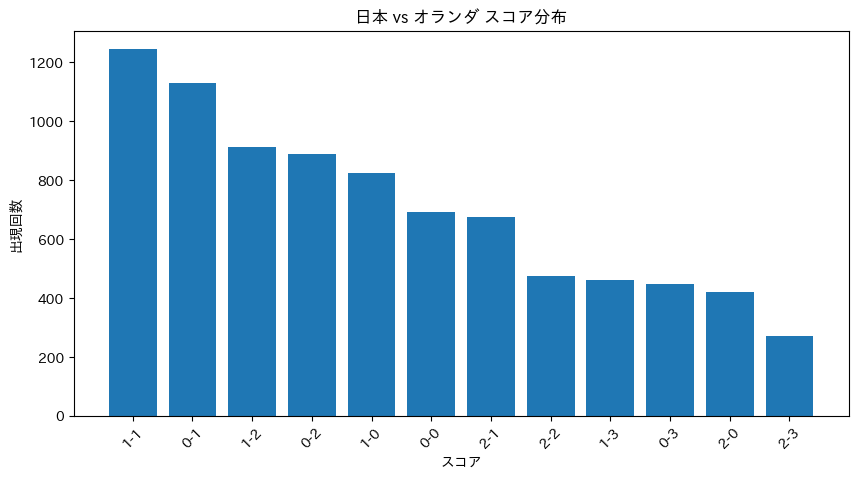

試合シミュレーション結果


,対戦カード,日本勝利,引き分け,スウェーデン勝利,日本期待得点,スウェーデン期待得点,最頻スコア
0,日本 vs スウェーデン,34.77%,26.21%,39.02%,1.25,1.35,1-1



出やすいスコア TOP12


,スコア,回数,確率
8,1-1,1221,12.21
3,0-1,1012,10.12
12,1-0,927,9.27
9,1-2,867,8.67
0,2-1,795,7.95
2,0-0,726,7.26
11,0-2,690,6.90
10,2-0,579,5.79
5,2-2,550,5.50
1,1-3,378,3.78


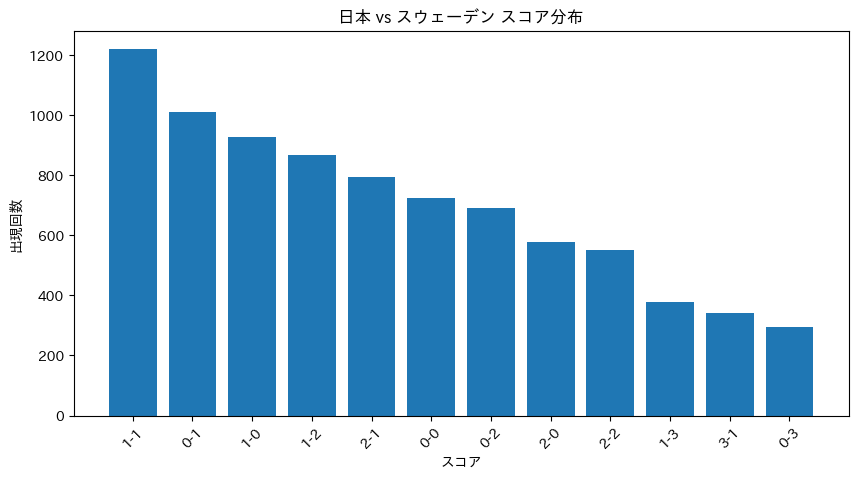

試合シミュレーション結果


,対戦カード,日本勝利,引き分け,チュニジア勝利,日本期待得点,チュニジア期待得点,最頻スコア
0,日本 vs チュニジア,47.3%,25.76%,26.94%,1.5,1.1,1-1



出やすいスコア TOP12


,スコア,回数,確率
6,1-1,1202,12.02
5,1-0,1105,11.05
11,2-0,909,9.09
4,2-1,899,8.99
2,0-1,792,7.92
1,0-0,759,7.59
12,1-2,635,6.35
7,2-2,516,5.16
0,3-1,480,4.80
3,0-2,461,4.61


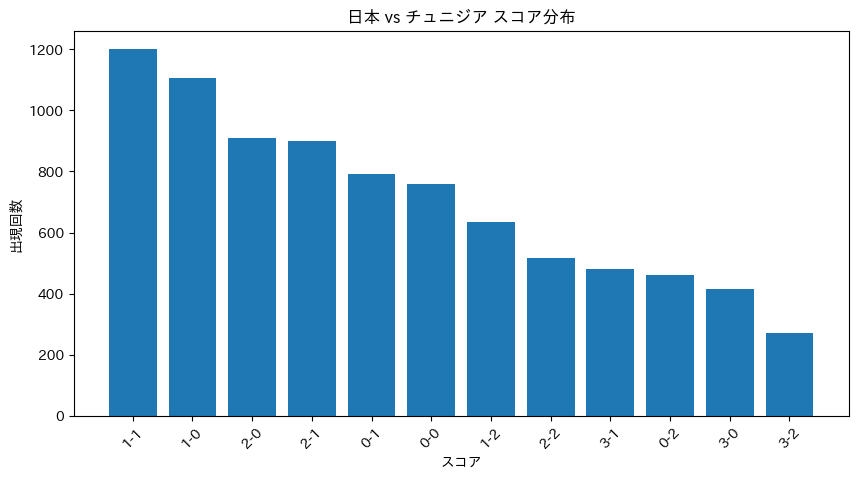

In [ ]:

# 3. 日本のグループ3試合まとめ

JAPAN_GROUP_MATCHES = [
    ("Japan", "Netherlands"),
    ("Japan", "Sweden"),
    ("Japan", "Tunisia"),
]

japan_match_results = []

for team_a, team_b in JAPAN_GROUP_MATCHES:
    result = simulate_match_many_fast(
        team_a,
        team_b,
        players_scored,
        n=10000,
        seed=42
    )

    japan_match_results.append({
        "対戦カード": f"{country_ja(team_a)} vs {country_ja(team_b)}",
        "日本勝利": result["team_a_win_rate"],
        "引き分け": result["draw_rate"],
        "相手勝利": result["team_b_win_rate"],
        "相手": country_ja(team_b),
        "日本期待得点": result["xg_a"],
        "相手期待得点": result["xg_b"],
        "最頻スコア": result["most_common_score"]
    })

japan_match_df = pd.DataFrame(japan_match_results)

print("==================================================")
print("日本のグループ3試合シミュレーション")
print("==================================================")
display(japan_match_df)

print("==================================================")
print("日本のグループ3試合 グラフ")
print("==================================================")

for team_a, team_b in JAPAN_GROUP_MATCHES:
    result = simulate_match_many_fast(
        team_a,
        team_b,
        players_scored,
        n=10000,
        seed=42
    )

    show_match_result_ja(result)